# 04 Predictive Modelling of Annual Airbnb Revenue

## 1. Notebook Setup

This notebook develops and evaluates machine learning models for predicting annual Airbnb revenue.

The main modelling objective is to estimate `Annual Revenue LTM (USD)` using property, location, host and amenity characteristics. The analysis will compare a simple baseline with several regression models and assess their performance using MAE, RMSE and R².

To reduce the risk of data leakage, variables that describe realised booking activity during the same twelve-month period as the target revenue will not be included in the main investment-stage model.

In [86]:
# Impoting libraries
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.container import BarContainer
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import KFold, cross_validate

import joblib
warnings.filterwarnings("ignore")

In [2]:
# Project paths

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

FIGURES_DIR = PROJECT_ROOT / "figures"
TABLES_DIR = PROJECT_ROOT / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_DATA_PATH = PROCESSED_DATA_DIR / "airbnb_cleaned.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Clean dataset: {CLEAN_DATA_PATH}")

Project root: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business
Clean dataset: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\data\processed\airbnb_cleaned.csv


In [3]:
# Project Colour Palette

PROJECT_COLOURS = {
    "primary": "#1f77b4",
    "secondary": "#ff7f0e",
    "success": "#2ca02c",
    "danger": "#d62728",
    "warning": "#bcbd22",
    "purple": "#9467bd",
    "grey": "#7f7f7f",
    "light_grey": "#d9d9d9",
    "dark": "#333333"
}

PROJECT_PALETTE = [
    PROJECT_COLOURS["primary"],
    PROJECT_COLOURS["secondary"],
    PROJECT_COLOURS["success"],
    PROJECT_COLOURS["danger"],
    PROJECT_COLOURS["purple"],
    PROJECT_COLOURS["warning"],
    PROJECT_COLOURS["grey"]
]

sns.set_palette(PROJECT_PALETTE)

In [4]:
# Plot Settings

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "figure.autolayout": False,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "normal",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,
    "legend.title_fontsize": 10,

    "font.size": 11,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "grid.alpha": 0.25,
    "grid.linestyle": "--"
})

In [5]:
# Figure-saving function

from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea

def save_figure(
    fig,
    number,
    filename,
    title=None,
    dpi=300,
    file_format="png"
):
    """
    Save one Matplotlib figure with a centred caption.

    The figure number is bold and the title is italic.
    """

    safe_filename = (
        filename.strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    output_path = (
        FIGURES_DIR
        / f"figure_{number:02d}_{safe_filename}.{file_format}"
    )

    # Reserve sufficient space beneath the chart
    fig.tight_layout(
        rect=[0.03, 0.10, 0.97, 0.98]
    )

    if title:
        figure_number_text = TextArea(
            f"Figure {number}. ",
            textprops={
                "fontsize": 11,
                "fontweight": "bold"
            }
        )

        figure_title_text = TextArea(
            title,
            textprops={
                "fontsize": 11,
                "fontstyle": "italic"
            }
        )

        complete_caption = HPacker(
            children=[
                figure_number_text,
                figure_title_text
            ],
            align="center",
            pad=0,
            sep=0
        )

        caption_box = AnchoredOffsetbox(
            loc="lower center",
            child=complete_caption,
            frameon=False,
            bbox_to_anchor=(0.5, 0.018),
            bbox_transform=fig.transFigure,
            borderpad=0
        )

        fig.add_artist(caption_box)

    fig.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"Figure {number} saved.")
    print(f"Location: {output_path}")

    return output_path

In [6]:
# Table-saving function

def save_table(
    dataframe,
    number,
    filename,
    index=False
):
    """
    Save one DataFrame as a numbered CSV file.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Table to save.
    number : int
        Sequential table number.
    filename : str
        Descriptive filename without table number or extension.
    index : bool, default=False
        Whether to save the DataFrame index.
    """

    safe_filename = (
        filename.strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    output_path = (
        TABLES_DIR
        / f"table_{number:02d}_{safe_filename}.csv"
    )

    dataframe.to_csv(
        output_path,
        index=index
    )

    print(f"Table {number} saved.")
    print(f"Location: {output_path}")

    return output_path

In [7]:
# Chart-Formatting Function

def format_chart(
    ax,
    title=None,
    xlabel=None,
    ylabel=None,
    show_grid=True,
    grid_axis="y",
    rotate_x=False
):
    """
    Apply consistent project formatting to a Matplotlib chart.
    """

    if title:
        ax.set_title(
            title,
            fontsize=13,
            fontweight="bold",
            pad=15
        )

    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if show_grid:
        ax.grid(
            visible=True,
            axis=grid_axis,
            linestyle="--",
            alpha=0.25
        )
    else:
        ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if rotate_x:
        plt.setp(
            ax.get_xticklabels(),
            rotation=45,
            ha="right"
        )

    return ax

In [8]:
# Axis-Formatting Functions

def format_currency_axis(ax, axis="y", decimals=0):
    """
    Format an axis as US dollars.
    """

    formatter = mtick.StrMethodFormatter(
        "${x:,.%df}" % decimals
    )

    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    elif axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        raise ValueError("axis must be either 'x' or 'y'.")

    return ax


def format_percentage_axis(ax, axis="y", decimals=0):
    """
    Format an axis whose values are already expressed from 0 to 100.
    """

    formatter = mtick.StrMethodFormatter(
        "{x:,.%df}%%" % decimals
    )

    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    elif axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        raise ValueError("axis must be either 'x' or 'y'.")

    return ax


def format_number_axis(ax, axis="y", decimals=0):
    """
    Add thousands separators to a numerical axis.
    """

    formatter = mtick.StrMethodFormatter(
        "{x:,.%df}" % decimals
    )

    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    elif axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        raise ValueError("axis must be either 'x' or 'y'.")

    return ax

In [9]:
# Bar-Label Function

def add_bar_labels(
    ax,
    decimals=0,
    prefix="",
    suffix="",
    padding=3
):
    """
    Add formatted value labels to vertical or horizontal bar charts.
    """

    for container in ax.containers:

        if not isinstance(container, BarContainer):
            continue

        labels = []

        for bar in container:
            height = bar.get_height()
            width = bar.get_width()

            # Use width for horizontal bars and height for vertical bars
            value = width if width > height else height

            if pd.isna(value):
                labels.append("")
            else:
                labels.append(
                    f"{prefix}{value:,.{decimals}f}{suffix}"
                )

        ax.bar_label(
            container,
            labels=labels,
            padding=padding,
            fontsize=9
        )

    return ax

# 2. Load and Validate the Cleaned Dataset

The cleaned Airbnb dataset produced in Notebook 2 is loaded for predictive modelling. Before building any models, the dataset is validated to confirm its structure, data types and the availability of the target variable and engineered features.

In [10]:
# Load the cleaned dataset

airbnb = pd.read_csv(CLEAN_DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Rows: {airbnb.shape[0]:,}")
print(f"Columns: {airbnb.shape[1]}")

Dataset loaded successfully.
Rows: 145,825
Columns: 50


In [11]:
airbnb.head()

,Listing Title,Property Type,Listing Type,Created Date,Last Scraped Date,Country,City,Zipcode,Number of Reviews,Bedrooms,...,Average Daily Rate (USD),Annual Revenue LTM (USD),State,Has Wifi,Has Kitchen,Has Parking,Has Pool,Has Air Conditioning,Has Washer,Listing Age (Days)
0,Spacious & Private Townhome | 5 mins drive to ...,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,1,3,...,145,3126,NaN,1,1,1,1,1,1,163.0
1,Spacious and Ornate 2BR Apartment in Dubai South,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,24,2,...,79,21815,NaN,1,1,1,1,1,1,163.0
2,Exceptional 2BR near Expo City Dubai!,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,13,2,...,70,14717,NaN,1,1,1,1,1,1,163.0
3,Stylish Apartment Surrounded by Lush Green Parks!,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,12,2,...,192,41775,NaN,1,1,1,1,1,0,163.0
4,OFFER! 50% OFF! I am very cool and sleep 6!,Entire condo,entire_home,2023-07-31,2024-01-03,AE,Dubai,25314,10,2,...,74,4461,NaN,1,1,1,1,1,1,156.0


In [12]:
# Variables containing missing values

missing_summary = (
    airbnb
    .isna()
    .sum()
    .rename("Missing Values")
    .to_frame()
)

missing_summary["Percentage"] = (
    missing_summary["Missing Values"]
    / len(airbnb)
    * 100
)

missing_summary = (
    missing_summary[
        missing_summary["Missing Values"] > 0
    ]
    .sort_values(
        by="Percentage",
        ascending=False
    )
)

missing_summary

,Missing Values,Percentage
Cancellation Policy,63517,43.557003
Host Listing Count,59101,40.528716
Airbnb Cleanliness Rating,21646,14.843820
Overall Rating,20851,14.298646
Airbnb Value Rating,19494,13.368078
Airbnb Checkin Rating,19493,13.367392
Airbnb Location Rating,19492,13.366707
Airbnb Accuracy Rating,19491,13.366021
Airbnb Communication Rating,19490,13.365335
Zipcode,15842,10.863706


In [13]:
# Summary statistics for the target variable

airbnb["Annual Revenue LTM (USD)"].describe()

count    1.458250e+05
mean     1.795272e+04
std      2.588228e+04
min      2.000000e+00
25%      2.916000e+03
50%      9.150000e+03
75%      2.323400e+04
max      1.290235e+06
Name: Annual Revenue LTM (USD), dtype: float64

In [14]:
# Confirm engineered features are present

engineered_features = [
    "Has Wifi",
    "Has Kitchen",
    "Has Parking",
    "Has Pool",
    "Has Air Conditioning",
    "Has Washer",
    "Listing Age (Days)"
]

available = [
    feature
    for feature in engineered_features
    if feature in airbnb.columns
]

print("Engineered features found:")

for feature in available:
    print(f"✓ {feature}")

Engineered features found:
✓ Has Wifi
✓ Has Kitchen
✓ Has Parking
✓ Has Pool
✓ Has Air Conditioning
✓ Has Washer
✓ Listing Age (Days)


### Validation Summary
The cleaned dataset loaded successfully and contains 145,825 Airbnb listings with all engineered variables created during preprocessing. The target variable, `Annual Revenue LTM (USD)`, is available for modelling, and the remaining missing values correspond to variables intentionally retained during the data cleaning stage. The dataset is therefore ready for feature selection and predictive modelling.

# 3. Define the Modelling Problem

The objective of the predictive modelling stage is to estimate the annual revenue generated by an Airbnb listing using characteristics that are available before or during the operation of the property.

The primary modelling task is regression because the target variable, **Annual Revenue LTM (USD)**, is continuous. Two modelling scenarios will be developed:

- **Investment-stage model:** uses property, host and amenity characteristics that are known before or when launching a listing.
- **Pricing-informed model:** extends the investment model by including Average Daily Rate (ADR) to evaluate the additional predictive value of pricing.

Variables that directly describe realised booking performance during the same twelve-month period as the target revenue are excluded from the primary model to reduce the risk of data leakage.

In [15]:
# Define the target variable

TARGET = "Annual Revenue LTM (USD)"

print(f"Target variable: {TARGET}")

Target variable: Annual Revenue LTM (USD)


In [16]:
# Log-transform the target variable

airbnb["Log Annual Revenue"] = np.log1p(
    airbnb[TARGET]
)

Figure 17 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_17_target_distribution_comparison.png


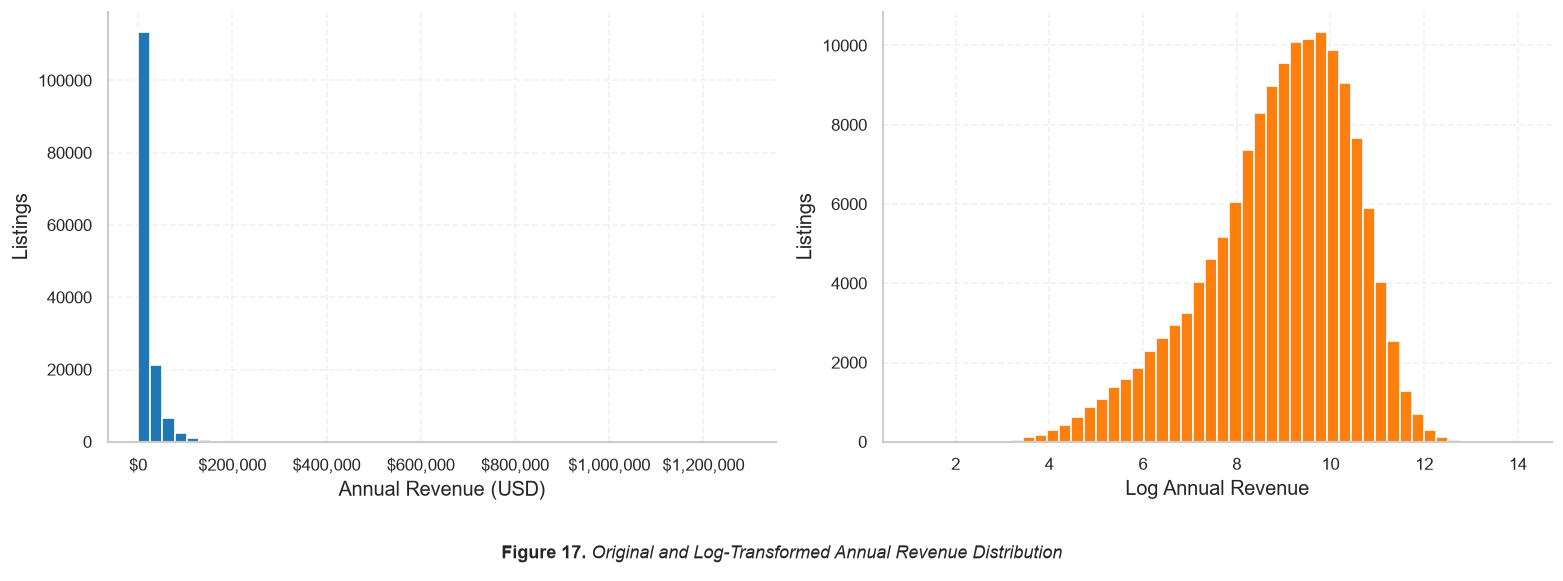

In [17]:
# Figure 17. Original and Log-Transformed Annual Revenue Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    airbnb[TARGET],
    bins=50,
    color=PROJECT_COLOURS["primary"],
    edgecolor="white"
)

format_chart(
    axes[0],
    title=None,
    xlabel="Annual Revenue (USD)",
    ylabel="Listings"
)

format_currency_axis(
    axes[0],
    axis="x"
)

axes[1].hist(
    airbnb["Log Annual Revenue"],
    bins=50,
    color=PROJECT_COLOURS["secondary"],
    edgecolor="white"
)

format_chart(
    axes[1],
    title=None,
    xlabel="Log Annual Revenue",
    ylabel="Listings"
)

plt.tight_layout()

save_figure(
    fig,
    number=17,
    filename="target_distribution_comparison",
    title="Original and Log-Transformed Annual Revenue Distribution"
)

plt.show()

Annual revenue is strongly right-skewed, with a small number of luxury listings generating exceptionally high income.

Applying a logarithmic transformation reduces the influence of extreme values, produces a more balanced target distribution and often improves the performance of regression models. Predictions will later be converted back to US dollars for interpretation.

Average Daily Rate Transformation

Average Daily Rate (ADR) is an important pricing variable. Examination of the original ADR distribution showed substantial positive skew, with a small number of listings charging exceptionally high nightly rates.

Highly skewed numerical variables can disproportionately influence regression-based models and may violate assumptions of linearity. To reduce the influence of extreme values and to preserve the relative ordering of observations, a logarithmic transformation (`log1p`) was applied.

In [18]:
# Create a log-transformed Average Daily Rate feature

airbnb["Log ADR"] = np.log1p(
    airbnb["Average Daily Rate (USD)"]
)

In [19]:
airbnb[
    [
        "Average Daily Rate (USD)",
        "Log ADR"
    ]
].describe()

,Average Daily Rate (USD),Log ADR
count,145825.000000,145825.000000
mean,198.687050,4.988587
std,238.648368,0.746926
min,1.000000,0.693147
25%,86.000000,4.465908
50%,143.000000,4.969813
75%,235.000000,5.463832
max,33553.000000,10.420911


Figure 18 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_18_adr_transformation_comparison.png


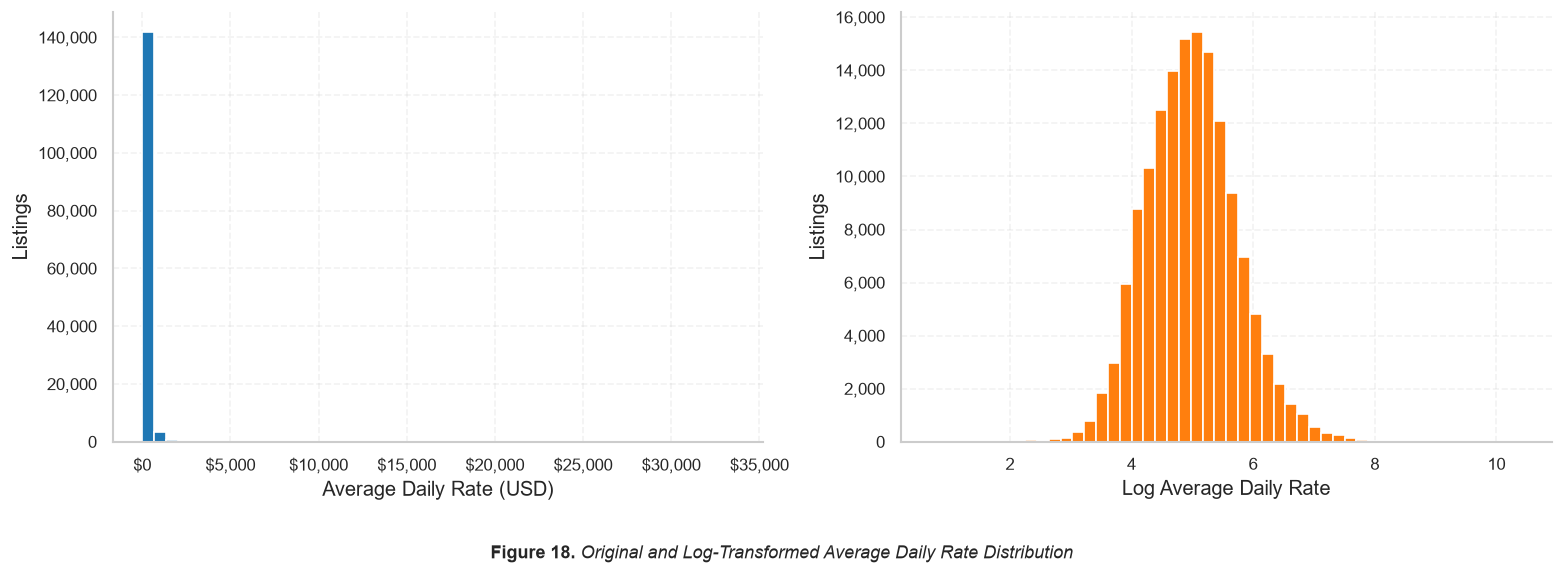

In [20]:
# Figure 18. Original and Log-Transformed ADR Distribution

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Original ADR distribution
axes[0].hist(
    airbnb["Average Daily Rate (USD)"],
    bins=50,
    color=PROJECT_COLOURS["primary"],
    edgecolor="white"
)

format_chart(
    axes[0],
    title=None,
    xlabel="Average Daily Rate (USD)",
    ylabel="Listings"
)

format_currency_axis(
    axes[0],
    axis="x"
)

format_number_axis(
    axes[0],
    axis="y"
)

# Log-transformed ADR distribution
axes[1].hist(
    airbnb["Log ADR"],
    bins=50,
    color=PROJECT_COLOURS["secondary"],
    edgecolor="white"
)

format_chart(
    axes[1],
    title=None,
    xlabel="Log Average Daily Rate",
    ylabel="Listings"
)

format_number_axis(
    axes[1],
    axis="y"
)

save_figure(
    fig,
    number=18,
    filename="adr_transformation_comparison",
    title="Original and Log-Transformed Average Daily Rate Distribution"
)

plt.show()

Figure 18 shows that the original ADR distribution contains a long right tail caused by a small number of unusually expensive listings. The logarithmic transformation compresses these extreme values and creates a more balanced distribution.

# 3. Feature Selection and Data Leakage Prevention

Selecting appropriate input variables is a critical step in predictive modelling.

The objective of this analysis is to estimate annual Airbnb revenue using information that would realistically be available at different stages of the Airbnb business lifecycle. Four modelling scenarios are developed, ranging from pre-investment property assessment to pricing strategy, allowing the contribution of additional information to be evaluated progressively.

Variables that describe realised booking performance over the same twelve-month period as the target variable are excluded because they would introduce data leakage. The four modelling scenarios differ only in the information available at each business stage, enabling fair comparison of model performance.

In [21]:
# Variables excluded from the primary investment model

leakage_features = [

    # Target
    "Annual Revenue LTM (USD)",
    "Log Annual Revenue",

    # Direct revenue components
    "Average Daily Rate (USD)",
    "Occupancy Rate LTM",
    "Number of Bookings LTM",
    "Count Reservation Days LTM",
    "Count Available Days LTM",
    "Count Blocked Days LTM",
    "Number of Bookings LTM - Number of observed month"
]

print("Variables excluded because of data leakage:\n")

for variable in leakage_features:
    print(f"• {variable}")

Variables excluded because of data leakage:

• Annual Revenue LTM (USD)
• Log Annual Revenue
• Average Daily Rate (USD)
• Occupancy Rate LTM
• Number of Bookings LTM
• Count Reservation Days LTM
• Count Available Days LTM
• Count Blocked Days LTM
• Number of Bookings LTM - Number of observed month


In [22]:
# Candidate features for the investment-stage model

investment_features = [

    # Property
    "Property Type",
    "Listing Type",
    "Bedrooms",
    "Bathrooms",
    "Max Guests",

    # Location
    "City",

    # Host
    "Airbnb Superhost",
    "Host Listing Count",

    # Policies
    "Cancellation Policy",

    # Amenities
    "Has Wifi",
    "Has Kitchen",
    "Has Parking",
    "Has Pool",
    "Has Air Conditioning",
    "Has Washer",

    # Property history
    "Listing Age (Days)"
]

print(f"Investment model features: {len(investment_features)}")

Investment model features: 16


In [23]:
# Feature matrix and target

X = airbnb[investment_features].copy()

y = airbnb["Log Annual Revenue"].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (145825, 16)
y shape: (145825,)


In [24]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical variables")
print(categorical_features)

print()

print("Numeric variables")
print(numeric_features)

Categorical variables
['Property Type', 'Listing Type', 'City', 'Airbnb Superhost', 'Cancellation Policy']

Numeric variables
['Bedrooms', 'Bathrooms', 'Max Guests', 'Host Listing Count', 'Has Wifi', 'Has Kitchen', 'Has Parking', 'Has Pool', 'Has Air Conditioning', 'Has Washer', 'Listing Age (Days)']


## 3.1 Definition of Modelling Scenarios

Four feature variants are used to represent different stages of Airbnb decision-making:

- **Model A, Investment Screening:** uses only property, location, policy and amenity information available before launching a listing.
- **Model B1, Listing Performance:** adds information available after the listing begins operating, but excludes Host Listing Count.
- **Model B2, Listing Performance with Host Portfolio:** adds Host Listing Count, with missing values handled inside the modelling pipeline.
- **Model C, Pricing Strategy:** extends the better operational specification by adding Average Daily Rate.

Booking counts, occupancy and reservation-day variables are excluded because they describe realised activity from the same period as annual revenue and could introduce data leakage.

In [25]:
# Model A: Investment Screening Model

investment_features = [
    "Property Type",
    "Listing Type",
    "Bedrooms",
    "Bathrooms",
    "Max Guests",
    "City",
    "Cancellation Policy",
    "Has Wifi",
    "Has Kitchen",
    "Has Parking",
    "Has Pool",
    "Has Air Conditioning",
    "Has Washer"
]


# Model B1: Listing Performance Model
# Adds operational information but excludes Host Listing Count

listing_features_b1 = investment_features + [
    "Airbnb Superhost",
    "Listing Age (Days)"
]


# Model B2: Listing Performance Model with Host Portfolio
# Host Listing Count will be median-imputed inside the pipeline

listing_features_b2 = listing_features_b1 + [
    "Host Listing Count"
]


# Model C: Pricing Strategy Model
# Uses the fuller operational feature set plus ADR

pricing_features = listing_features_b2 + [
    "Log ADR"
]


print(f"Model A features:  {len(investment_features)}")
print(f"Model B1 features: {len(listing_features_b1)}")
print(f"Model B2 features: {len(listing_features_b2)}")
print(f"Model C features:  {len(pricing_features)}")

Model A features:  13
Model B1 features: 15
Model B2 features: 16
Model C features:  17


In [26]:
# Create a comparison table showing the variables used in each model

all_model_features = list(
    dict.fromkeys(
        investment_features
        + listing_features_b1
        + listing_features_b2
        + pricing_features
    )
)

feature_comparison = pd.DataFrame({
    "Variable": all_model_features,
    "Model A: Investment": [
        "✓" if feature in investment_features else ""
        for feature in all_model_features
    ],
    "Model B1: Listing": [
        "✓" if feature in listing_features_b1 else ""
        for feature in all_model_features
    ],
    "Model B2: Host Portfolio": [
        "✓" if feature in listing_features_b2 else ""
        for feature in all_model_features
    ],
    "Model C: Pricing": [
        "✓" if feature in pricing_features else ""
        for feature in all_model_features
    ]
})

feature_comparison

,Variable,Model A: Investment,Model B1: Listing,Model B2: Host Portfolio,Model C: Pricing
0,Property Type,✓,✓,✓,✓
1,Listing Type,✓,✓,✓,✓
2,Bedrooms,✓,✓,✓,✓
3,Bathrooms,✓,✓,✓,✓
4,Max Guests,✓,✓,✓,✓
5,City,✓,✓,✓,✓
6,Cancellation Policy,✓,✓,✓,✓
7,Has Wifi,✓,✓,✓,✓
8,Has Kitchen,✓,✓,✓,✓
9,Has Parking,✓,✓,✓,✓


In [27]:
save_table(
    dataframe=feature_comparison,
    number=18,
    filename="modelling_feature_comparison",
    index=False
)

Table 18 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_18_modelling_feature_comparison.csv


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_18_modelling_feature_comparison.csv')

Table 18 shows the progressive structure of the modelling analysis. Model A contains only variables suitable for pre-investment screening. Model B1 adds listing-level operational information, while Model B2 tests whether Host Listing Count adds predictive value despite its high missing-value rate. Model C adds ADR to measure the contribution of pricing information. This staged approach allows changes in model performance to be linked to specific groups of business information.

In [28]:
# Define the original and log-transformed targets

TARGET_RAW = "Annual Revenue LTM (USD)"
TARGET_LOG = "Log Annual Revenue"

y_raw = airbnb[TARGET_RAW].copy()
y = airbnb[TARGET_LOG].copy()

print(f"Original target shape: {y_raw.shape}")
print(f"Model target shape:    {y.shape}")
print(f"Missing target values: {y.isna().sum():,}")

Original target shape: (145825,)
Model target shape:    (145825,)
Missing target values: 0


In [29]:
# Create separate feature matrices for each modelling scenario

X_investment = airbnb[investment_features].copy()
X_listing_b1 = airbnb[listing_features_b1].copy()
X_listing_b2 = airbnb[listing_features_b2].copy()
X_pricing = airbnb[pricing_features].copy()

print(f"Model A shape:  {X_investment.shape}")
print(f"Model B1 shape: {X_listing_b1.shape}")
print(f"Model B2 shape: {X_listing_b2.shape}")
print(f"Model C shape:  {X_pricing.shape}")

Model A shape:  (145825, 13)
Model B1 shape: (145825, 15)
Model B2 shape: (145825, 16)
Model C shape:  (145825, 17)


In [30]:
# Store the four business scenarios in one dictionary

business_models = {
    "Model A - Investment Screening": X_investment,
    "Model B1 - Listing Performance": X_listing_b1,
    "Model B2 - Host Portfolio": X_listing_b2,
    "Model C - Pricing Strategy": X_pricing
}

print("Business modelling scenarios created.")

for scenario_name, X_data in business_models.items():
    print(f"{scenario_name}: {X_data.shape[1]} features")

Business modelling scenarios created.
Model A - Investment Screening: 13 features
Model B1 - Listing Performance: 15 features
Model B2 - Host Portfolio: 16 features
Model C - Pricing Strategy: 17 features


In [31]:
# Missing-value rates across all selected modelling variables

selected_features = list(
    dict.fromkeys(pricing_features)
)

modelling_missing_summary = pd.DataFrame({
    "Missing Values": airbnb[selected_features].isna().sum(),
    "Missing (%)": (
        airbnb[selected_features].isna().mean() * 100
    )
})

modelling_missing_summary = (
    modelling_missing_summary[
        modelling_missing_summary["Missing Values"] > 0
    ]
    .sort_values("Missing (%)", ascending=False)
)

modelling_missing_summary.round(2)

,Missing Values,Missing (%)
Cancellation Policy,63517,43.56
Host Listing Count,59101,40.53
Listing Age (Days),900,0.62


# 4. Data Preprocessing Pipeline

Before training machine learning models, the selected variables require preprocessing.

Numerical and categorical variables are processed using a scikit-learn pipeline to ensure that all transformations are applied consistently. Importantly, preprocessing is fitted only on the training data and then applied to the test data, preventing data leakage.

The preprocessing pipeline performs the following steps:

- Median imputation for numerical variables.
- "Unknown" imputation for missing categorical values.
- One-hot encoding of categorical variables.
- Standardisation of numerical variables where appropriate.

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.model_selection import train_test_split

In [33]:
def create_linear_preprocessor(X):
    """
    Create preprocessing for Linear Regression.

    Numerical variables:
    - median imputation
    - standardisation

    Categorical variables:
    - missing values replaced with 'Unknown'
    - one-hot encoding
    """

    numeric_features = X.select_dtypes(
        include=["number"]
    ).columns.tolist()

    categorical_features = X.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="Unknown"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

    return preprocessor

In [34]:
def create_tree_preprocessor(X):
    """
    Create preprocessing for Decision Tree and Random Forest models.

    Numerical variables:
    - median imputation
    - no scaling

    Categorical variables:
    - missing values replaced with 'Unknown'
    - one-hot encoding
    """

    numeric_features = X.select_dtypes(
        include=["number"]
    ).columns.tolist()

    categorical_features = X.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="Unknown"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

    return preprocessor

In [35]:
linear_preprocessor = create_linear_preprocessor(
    X_investment
)

tree_preprocessor = create_tree_preprocessor(
    X_investment
)

print("Linear preprocessor created.")
print("Tree preprocessor created.")

Linear preprocessor created.
Tree preprocessor created.


# 5. Reusable Model Training and Evaluation

A reusable function is used to train and evaluate all regression models consistently.

Each model uses the same 80:20 train-test split. The preprocessing pipeline is fitted only on the training data, preventing information from the test set from influencing model development.

Model performance is evaluated using:

- **Mean Absolute Error (MAE):** the average absolute prediction error in US dollars.
- **Root Mean Squared Error (RMSE):** gives greater weight to large prediction errors.
- **R²:** the proportion of variation in annual revenue explained by the model.

Predictions are generated on the log-transformed target and then converted back into US dollars for business interpretation.

In [36]:
# Create one fixed train-test split for all modelling scenarios

train_index, test_index = train_test_split(
    airbnb.index,
    test_size=0.20,
    random_state=42
)

y_train = y.loc[train_index]
y_test = y.loc[test_index]

y_raw_train = y_raw.loc[train_index]
y_raw_test = y_raw.loc[test_index]

print(f"Training observations: {len(train_index):,}")
print(f"Testing observations:  {len(test_index):,}")

Training observations: 116,660
Testing observations:  29,165


In [37]:
def train_and_evaluate_regressor(
    X,
    model,
    model_name,
    business_scenario,
    preprocessor_type="tree"
):
    """
    Train and evaluate one regression model.

    Parameters
    ----------
    X : pandas.DataFrame
        Feature matrix for one business scenario.
    model : scikit-learn estimator
        Regression algorithm to train.
    model_name : str
        Name of the regression algorithm.
    business_scenario : str
        Name of the business feature scenario.
    preprocessor_type : {"linear", "tree"}, default="tree"
        Determines whether numerical variables are standardised.

    Returns
    -------
    result : dict
        Model performance metrics.
    fitted_pipeline : sklearn.pipeline.Pipeline
        Complete fitted preprocessing and modelling pipeline.
    prediction_output : pandas.DataFrame
        Actual values, predictions and residuals for the test set.
    """

    # Use the same train-test rows for every model
    X_train = X.loc[train_index]
    X_test = X.loc[test_index]

    # Select preprocessing appropriate to the algorithm
    if preprocessor_type == "linear":
        preprocessor = create_linear_preprocessor(X_train)

    elif preprocessor_type == "tree":
        preprocessor = create_tree_preprocessor(X_train)

    else:
        raise ValueError(
            "preprocessor_type must be either 'linear' or 'tree'."
        )

    # Combine preprocessing and regression model
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train the complete pipeline
    pipeline.fit(
        X_train,
        y_train
    )

    # Predict log-transformed revenue
    predictions_log = pipeline.predict(X_test)

    # Convert predictions back to US dollars
    predictions_usd = np.expm1(predictions_log)

    # Prevent impossible negative revenue predictions
    predictions_usd = np.clip(
        predictions_usd,
        a_min=0,
        a_max=None
    )

    # Calculate residuals in original dollar scale
    residuals_usd = (
        y_raw_test.to_numpy()
        - predictions_usd
    )

    # Evaluation metrics in original dollar scale
    mae = mean_absolute_error(
        y_raw_test,
        predictions_usd
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_raw_test,
            predictions_usd
        )
    )

    r2 = r2_score(
        y_test,
        predictions_log
    )

    # Number of predictors after preprocessing
    p = (
        pipeline.named_steps["preprocessor"]
        .transform(X_train.iloc[:1])
        .shape[1]
    )

    # Number of observations
    n = len(y_test)

    # Adjusted R²
    adjusted_r2 = 1 - (
        (1 - r2) * (n - 1)
    ) / (
        n - p - 1
    )

    # Store metrics
    result = {
        "Business Scenario": business_scenario,
        "Algorithm": model_name,
        "Predictors": p,
        "MAE (USD)": mae,
        "RMSE (USD)": rmse,
        "R² (Log Scale)": r2,
        "Adjusted R² (Log Scale)": adjusted_r2
    }

    # Store predictions for later diagnostics
    prediction_output = pd.DataFrame(
        {
            "Actual Revenue (USD)": y_raw_test.to_numpy(),
            "Predicted Revenue (USD)": predictions_usd,
            "Residual (USD)": residuals_usd,
            "Actual Log Revenue": y_test.to_numpy(),
            "Predicted Log Revenue": predictions_log
        },
        index=test_index
    )

    print(f"{business_scenario} | {model_name}")
    print(f"MAE:         ${mae:,.2f}")
    print(f"RMSE:        ${rmse:,.2f}")
    print(f"R² (log):           {r2:.4f}")
    print(f"Adjusted R² (log):  {adjusted_r2:.4f}")
    print("-" * 55)

    return result, pipeline, prediction_output

In [38]:
def run_model(
    X,
    model,
    model_name,
    business_scenario,
    preprocessor_type
):
    """
    Train one model and store its metrics,
    fitted pipeline and prediction output.
    """

    result, pipeline, predictions = train_and_evaluate_regressor(
        X=X,
        model=model,
        model_name=model_name,
        business_scenario=business_scenario,
        preprocessor_type=preprocessor_type
    )

    model_key = f"{business_scenario} | {model_name}"

    model_results.append(result)
    fitted_models[model_key] = pipeline
    model_predictions[model_key] = predictions

    print(f"Stored model: {model_key}")

In [39]:
model_results = []
fitted_models = {}
model_predictions = {}

print("Result containers created.")

Result containers created.


run_model(
    X=X_investment,
    model=LinearRegression(),
    model_name="Linear Regression",
    business_scenario="Model A - Investment Screening",
    preprocessor_type="linear"
)

pd.DataFrame(model_results)

# 6. Linear Regression Models

Linear Regression provides a baseline model against which more complex machine learning algorithms can be compared. Four regression models are trained using progressively richer feature sets to evaluate how additional business information affects predictive performance.

In [40]:
# Train Linear Regression across all four business scenarios

for scenario_name, X_data in business_models.items():

    run_model(
        X=X_data,
        model=LinearRegression(),
        model_name="Linear Regression",
        business_scenario=scenario_name,
        preprocessor_type="linear"
    )

Model A - Investment Screening | Linear Regression
MAE:         $12,817.82
RMSE:        $23,858.72
R² (log):           0.2286
Adjusted R² (log):  0.2239
-------------------------------------------------------
Stored model: Model A - Investment Screening | Linear Regression
Model B1 - Listing Performance | Linear Regression
MAE:         $12,521.87
RMSE:        $23,619.25
R² (log):           0.2631
Adjusted R² (log):  0.2586
-------------------------------------------------------
Stored model: Model B1 - Listing Performance | Linear Regression
Model B2 - Host Portfolio | Linear Regression
MAE:         $12,512.08
RMSE:        $23,615.33
R² (log):           0.2644
Adjusted R² (log):  0.2598
-------------------------------------------------------
Stored model: Model B2 - Host Portfolio | Linear Regression
Model C - Pricing Strategy | Linear Regression
MAE:         $11,769.49
RMSE:        $21,373.30
R² (log):           0.3477
Adjusted R² (log):  0.3436
---------------------------------------

In [41]:
linear_results = (
    pd.DataFrame(model_results)
    .query("Algorithm == 'Linear Regression'")
    .sort_values("Business Scenario")
)

linear_results.round({
    "MAE (USD)": 2,
    "RMSE (USD)": 2,
    "R²": 4,
    "Adjusted R²": 4
})

,Business Scenario,Algorithm,Predictors,MAE (USD),RMSE (USD),R² (Log Scale),Adjusted R² (Log Scale)
0,Model A - Investment Screening,Linear Regression,176,12817.82,23858.72,0.228563,0.223879
1,Model B1 - Listing Performance,Linear Regression,179,12521.87,23619.25,0.263121,0.258570
2,Model B2 - Host Portfolio,Linear Regression,180,12512.08,23615.33,0.264365,0.259796
3,Model C - Pricing Strategy,Linear Regression,181,11769.49,21373.30,0.347652,0.343578


In [42]:
save_table(
    dataframe=linear_results,
    number=19,
    filename="linear_regression_results",
    index=False
)

Table 19 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_19_linear_regression_results.csv


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_19_linear_regression_results.csv')

# 7. Decision Tree Regression

Decision Tree Regression was used to capture non-linear relationships and interactions that Linear Regression may not represent effectively.

An unrestricted decision tree can closely fit the training data and perform poorly on unseen listings. The tree was therefore constrained using a maximum depth and a minimum number of observations per terminal leaf. These controls reduce overfitting and produce more stable predictions.

The same four business scenarios and the same train-test observations were used to ensure a fair comparison with Linear Regression.

In [43]:
# Train Decision Tree Regression across all four business scenarios

for scenario_name, X_data in business_models.items():

    run_model(
        X=X_data,
        model=DecisionTreeRegressor(
            max_depth=12,
            min_samples_leaf=20,
            random_state=42
        ),
        model_name="Decision Tree",
        business_scenario=scenario_name,
        preprocessor_type="tree"
    )

Model A - Investment Screening | Decision Tree
MAE:         $12,665.08
RMSE:        $23,553.57
R² (log):           0.2333
Adjusted R² (log):  0.2287
-------------------------------------------------------
Stored model: Model A - Investment Screening | Decision Tree
Model B1 - Listing Performance | Decision Tree
MAE:         $11,502.14
RMSE:        $21,530.73
R² (log):           0.3502
Adjusted R² (log):  0.3462
-------------------------------------------------------
Stored model: Model B1 - Listing Performance | Decision Tree
Model B2 - Host Portfolio | Decision Tree
MAE:         $11,403.61
RMSE:        $21,424.87
R² (log):           0.3573
Adjusted R² (log):  0.3533
-------------------------------------------------------
Stored model: Model B2 - Host Portfolio | Decision Tree
Model C - Pricing Strategy | Decision Tree
MAE:         $10,590.73
RMSE:        $19,426.52
R² (log):           0.4369
Adjusted R² (log):  0.4334
-------------------------------------------------------
Stored mode

In [44]:
decision_tree_results = (
    pd.DataFrame(model_results)
    .query("Algorithm == 'Decision Tree'")
    .sort_values("Business Scenario")
)

decision_tree_results.round({
    "MAE (USD)": 2,
    "RMSE (USD)": 2,
    "R² (Log Scale)": 4,
    "Adjusted R² (Log Scale)": 4
})

,Business Scenario,Algorithm,Predictors,MAE (USD),RMSE (USD),R² (Log Scale),Adjusted R² (Log Scale)
4,Model A - Investment Screening,Decision Tree,176,12665.08,23553.57,0.2333,0.2287
5,Model B1 - Listing Performance,Decision Tree,179,11502.14,21530.73,0.3502,0.3462
6,Model B2 - Host Portfolio,Decision Tree,180,11403.61,21424.87,0.3573,0.3533
7,Model C - Pricing Strategy,Decision Tree,181,10590.73,19426.52,0.4369,0.4334


In [45]:
save_table(
    dataframe=decision_tree_results,
    number=20,
    filename="decision_tree_regression_results",
    index=False
)

Table 20 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_20_decision_tree_regression_results.csv


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_20_decision_tree_regression_results.csv')

The Decision Tree models allow the relationship between listing characteristics and annual revenue to vary across different combinations of property, location and host features. Their results are compared with the Linear Regression baseline to determine whether modelling non-linear relationships improves predictive accuracy.

Particular attention is given to whether the addition of Host Listing Count materially improves Model B2 and whether pricing information strengthens Model C.

In [46]:
linear_tree_comparison = (
    pd.DataFrame(model_results)
    .query(
        "Algorithm in ['Linear Regression', 'Decision Tree']"
    )
    .sort_values(
        ["Business Scenario", "Algorithm"]
    )
)

linear_tree_comparison.round({
    "MAE (USD)": 2,
    "RMSE (USD)": 2,
    "R² (Log Scale)": 4,
    "Adjusted R² (Log Scale)": 4
})

,Business Scenario,Algorithm,Predictors,MAE (USD),RMSE (USD),R² (Log Scale),Adjusted R² (Log Scale)
4,Model A - Investment Screening,Decision Tree,176,12665.08,23553.57,0.2333,0.2287
0,Model A - Investment Screening,Linear Regression,176,12817.82,23858.72,0.2286,0.2239
5,Model B1 - Listing Performance,Decision Tree,179,11502.14,21530.73,0.3502,0.3462
1,Model B1 - Listing Performance,Linear Regression,179,12521.87,23619.25,0.2631,0.2586
6,Model B2 - Host Portfolio,Decision Tree,180,11403.61,21424.87,0.3573,0.3533
2,Model B2 - Host Portfolio,Linear Regression,180,12512.08,23615.33,0.2644,0.2598
7,Model C - Pricing Strategy,Decision Tree,181,10590.73,19426.52,0.4369,0.4334
3,Model C - Pricing Strategy,Linear Regression,181,11769.49,21373.30,0.3477,0.3436


Figure 19 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_19_linear_vs_decision_tree_r2.png


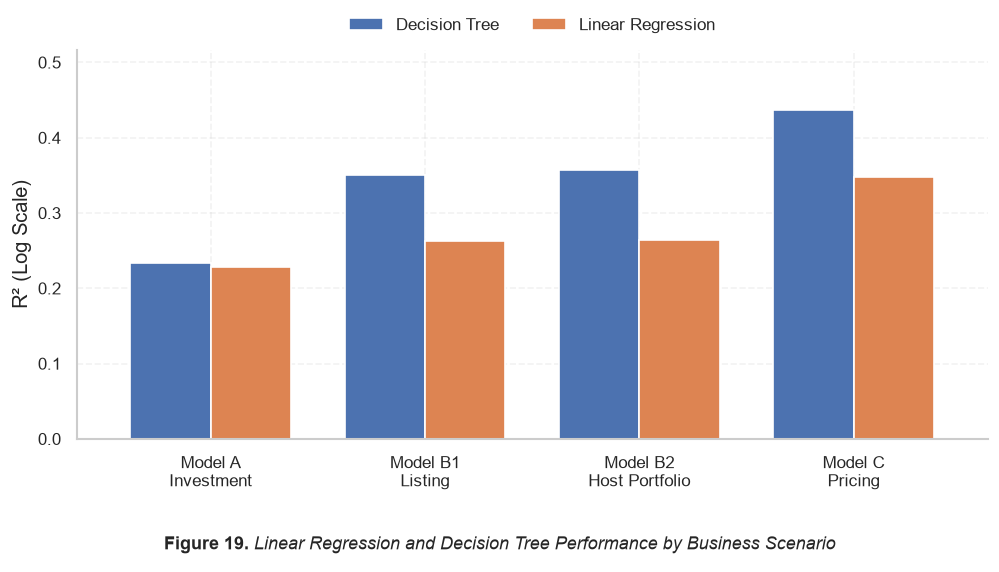

In [47]:
comparison_lr_dt = (
    pd.DataFrame(model_results)
    .query("Algorithm in ['Linear Regression', 'Decision Tree']")
)

pivot_r2 = comparison_lr_dt.pivot(
    index="Business Scenario",
    columns="Algorithm",
    values="R² (Log Scale)"
)

# Shorter two-line labels
scenario_labels = {
    "Model A - Investment Screening": "Model A\nInvestment",
    "Model B1 - Listing Performance": "Model B1\nListing",
    "Model B2 - Host Portfolio": "Model B2\nHost Portfolio",
    "Model C - Pricing Strategy": "Model C\nPricing"
}

pivot_r2 = pivot_r2.rename(index=scenario_labels)

fig, ax = plt.subplots(figsize=(9, 5))

pivot_r2.plot(
    kind="bar",
    ax=ax,
    width=0.75
)

format_chart(
    ax,
    title=None,
    xlabel="",
    ylabel="R² (Log Scale)"
)

# Keep labels horizontal and centred
plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    ha="center"
)

# Move legend above the plot
ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False
)

# Add a little headroom above the tallest bar
ax.set_ylim(
    0,
    pivot_r2.to_numpy().max() + 0.08
)

save_figure(
    fig,
    number=19,
    filename="linear_vs_decision_tree_r2",
    title="Linear Regression and Decision Tree Performance by Business Scenario"
)

plt.show()

# 8. Random Forest Regression

Random Forest Regression combines the predictions of many decision trees to improve stability and reduce the risk of overfitting associated with a single tree.

The model can capture non-linear relationships and interactions between property, host and pricing variables without requiring numerical features to be standardised. The same four business scenarios and fixed train-test split were used to ensure a fair comparison with Linear Regression and Decision Tree Regression.

In [48]:
# Train Random Forest Regression across all four business scenarios

for scenario_name, X_data in business_models.items():

    run_model(
        X=X_data,
        model=RandomForestRegressor(
            n_estimators=200,
            max_depth=14,
            min_samples_leaf=10,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ),
        model_name="Random Forest",
        business_scenario=scenario_name,
        preprocessor_type="tree"
    )

Model A - Investment Screening | Random Forest
MAE:         $13,043.07
RMSE:        $24,594.35
R² (log):           0.2205
Adjusted R² (log):  0.2158
-------------------------------------------------------
Stored model: Model A - Investment Screening | Random Forest
Model B1 - Listing Performance | Random Forest
MAE:         $12,354.34
RMSE:        $23,737.57
R² (log):           0.3042
Adjusted R² (log):  0.2999
-------------------------------------------------------
Stored model: Model B1 - Listing Performance | Random Forest
Model B2 - Host Portfolio | Random Forest
MAE:         $12,211.19
RMSE:        $23,508.12
R² (log):           0.3240
Adjusted R² (log):  0.3198
-------------------------------------------------------
Stored model: Model B2 - Host Portfolio | Random Forest
Model C - Pricing Strategy | Random Forest
MAE:         $11,791.55
RMSE:        $22,666.59
R² (log):           0.3805
Adjusted R² (log):  0.3766
-------------------------------------------------------
Stored mode

In [49]:
random_forest_results = (
    pd.DataFrame(model_results)
    .query("Algorithm == 'Random Forest'")
    .sort_values("Business Scenario")
)

random_forest_results.round({
    "MAE (USD)": 2,
    "RMSE (USD)": 2,
    "R² (Log Scale)": 4,
    "Adjusted R² (Log Scale)": 4
})

,Business Scenario,Algorithm,Predictors,MAE (USD),RMSE (USD),R² (Log Scale),Adjusted R² (Log Scale)
8,Model A - Investment Screening,Random Forest,176,13043.07,24594.35,0.2205,0.2158
9,Model B1 - Listing Performance,Random Forest,179,12354.34,23737.57,0.3042,0.2999
10,Model B2 - Host Portfolio,Random Forest,180,12211.19,23508.12,0.3240,0.3198
11,Model C - Pricing Strategy,Random Forest,181,11791.55,22666.59,0.3805,0.3766


In [50]:
save_table(
    dataframe=random_forest_results,
    number=21,
    filename="random_forest_regression_results",
    index=False
)

Table 21 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_21_random_forest_regression_results.csv


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_21_random_forest_regression_results.csv')

The Random Forest models are evaluated against the Linear Regression and Decision Tree baselines. The comparison focuses on whether combining multiple trees improves prediction accuracy and produces more stable results across the four business scenarios.

Particular attention is given to Model C, since it contains the richest feature set and represents the practical pricing strategy use case intended for the predictive dashboard.

In [51]:
# Random Forest Model Tuning

alternative_rf_results = []
tuned_rf_pipelines = {}
tuned_rf_predictions = {}

for scenario_name, X_data in business_models.items():

    result, pipeline, predictions = train_and_evaluate_regressor(
        X=X_data,
        model=RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ),
        model_name="Random Forest (Tuned)",
        business_scenario=scenario_name,
        preprocessor_type="tree"
    )

    alternative_rf_results.append(result)

    tuned_rf_pipelines[scenario_name] = pipeline
    tuned_rf_predictions[scenario_name] = predictions

Model A - Investment Screening | Random Forest (Tuned)
MAE:         $12,208.17
RMSE:        $22,688.62
R² (log):           0.2653
Adjusted R² (log):  0.2608
-------------------------------------------------------
Model B1 - Listing Performance | Random Forest (Tuned)
MAE:         $10,962.98
RMSE:        $20,809.47
R² (log):           0.4054
Adjusted R² (log):  0.4018
-------------------------------------------------------
Model B2 - Host Portfolio | Random Forest (Tuned)
MAE:         $10,649.99
RMSE:        $20,379.76
R² (log):           0.4262
Adjusted R² (log):  0.4226
-------------------------------------------------------
Model C - Pricing Strategy | Random Forest (Tuned)
MAE:         $9,827.87
RMSE:        $18,416.85
R² (log):           0.5039
Adjusted R² (log):  0.5008
-------------------------------------------------------


In [52]:
alternative_rf_results = (
    pd.DataFrame(alternative_rf_results)
    .sort_values("Business Scenario")
)

alternative_rf_results.round({
    "MAE (USD)": 2,
    "RMSE (USD)": 2,
    "R² (Log Scale)": 4,
    "Adjusted R² (Log Scale)": 4
})

,Business Scenario,Algorithm,Predictors,MAE (USD),RMSE (USD),R² (Log Scale),Adjusted R² (Log Scale)
0,Model A - Investment Screening,Random Forest (Tuned),176,12208.17,22688.62,0.2653,0.2608
1,Model B1 - Listing Performance,Random Forest (Tuned),179,10962.98,20809.47,0.4054,0.4018
2,Model B2 - Host Portfolio,Random Forest (Tuned),180,10649.99,20379.76,0.4262,0.4226
3,Model C - Pricing Strategy,Random Forest (Tuned),181,9827.87,18416.85,0.5039,0.5008


In [53]:
champion_scenario = "Model C - Pricing Strategy"

champion_pipeline = tuned_rf_pipelines[
    champion_scenario
]

champion_predictions = tuned_rf_predictions[
    champion_scenario
]

print(f"Champion model selected: {champion_scenario}")

Champion model selected: Model C - Pricing Strategy


The initial Random Forest model underperformed the Decision Tree across all four business scenarios. Inspection of the configuration suggested that the combination of shallow trees and restricted feature sampling was limiting model complexity. A second configuration was therefore evaluated with more flexible hyperparameters. The tuned Random Forest consistently achieved the highest predictive accuracy and was selected as the final model.

9. Comparison of All Models

In [54]:
final_model_results = (
    pd.concat(
        [
            pd.DataFrame(model_results)
            .query("Algorithm != 'Random Forest'"),

            alternative_rf_results.assign(
                Algorithm="Random Forest"
            )
        ],
        ignore_index=True
    )
)

In [55]:
all_model_results = (
    final_model_results
    .sort_values(
        ["Business Scenario", "R² (Log Scale)"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

all_model_results.round({
    "MAE (USD)": 2,
    "RMSE (USD)": 2,
    "R² (Log Scale)": 4,
    "Adjusted R² (Log Scale)": 4
})

,Business Scenario,Algorithm,Predictors,MAE (USD),RMSE (USD),R² (Log Scale),Adjusted R² (Log Scale)
0,Model A - Investment Screening,Random Forest,176,12208.17,22688.62,0.2653,0.2608
1,Model A - Investment Screening,Decision Tree,176,12665.08,23553.57,0.2333,0.2287
2,Model A - Investment Screening,Linear Regression,176,12817.82,23858.72,0.2286,0.2239
3,Model B1 - Listing Performance,Random Forest,179,10962.98,20809.47,0.4054,0.4018
4,Model B1 - Listing Performance,Decision Tree,179,11502.14,21530.73,0.3502,0.3462
5,Model B1 - Listing Performance,Linear Regression,179,12521.87,23619.25,0.2631,0.2586
6,Model B2 - Host Portfolio,Random Forest,180,10649.99,20379.76,0.4262,0.4226
7,Model B2 - Host Portfolio,Decision Tree,180,11403.61,21424.87,0.3573,0.3533
8,Model B2 - Host Portfolio,Linear Regression,180,12512.08,23615.33,0.2644,0.2598
9,Model C - Pricing Strategy,Random Forest,181,9827.87,18416.85,0.5039,0.5008


In [56]:
save_table(
    dataframe=all_model_results,
    number=22,
    filename="all_model_performance_comparison",
    index=False
)

Table 22 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_22_all_model_performance_comparison.csv


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_22_all_model_performance_comparison.csv')

Figure 20 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_20_all_algorithms_r2_comparison.png


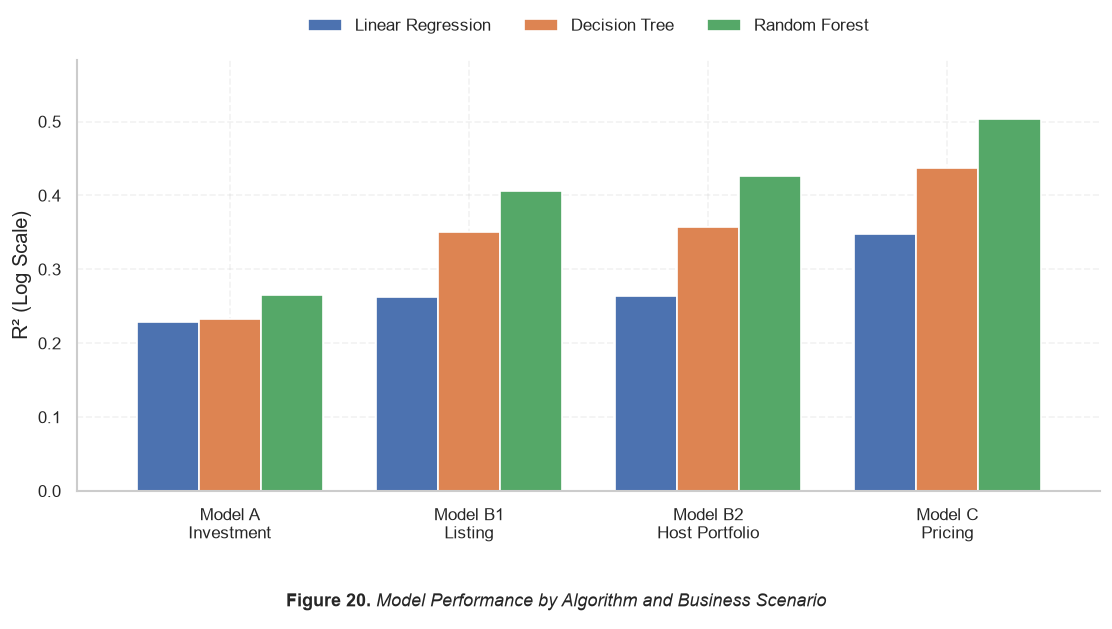

In [57]:
# Figure 20. Model Performance by Algorithm and Business Scenario

comparison_all = final_model_results.copy()

pivot_all_r2 = comparison_all.pivot(
    index="Business Scenario",
    columns="Algorithm",
    values="R² (Log Scale)"
)

scenario_labels = {
    "Model A - Investment Screening": "Model A\nInvestment",
    "Model B1 - Listing Performance": "Model B1\nListing",
    "Model B2 - Host Portfolio": "Model B2\nHost Portfolio",
    "Model C - Pricing Strategy": "Model C\nPricing"
}

pivot_all_r2 = pivot_all_r2.rename(
    index=scenario_labels
)

# Control legend order
algorithm_order = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest"
]

pivot_all_r2 = pivot_all_r2[
    algorithm_order
]

fig, ax = plt.subplots(figsize=(10, 5.5))

pivot_all_r2.plot(
    kind="bar",
    ax=ax,
    width=0.78
)

format_chart(
    ax,
    title=None,
    xlabel="",
    ylabel="R² (Log Scale)"
)

plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    ha="center"
)

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
    ncol=3,
    frameon=False
)

ax.set_ylim(
    0,
    pivot_all_r2.to_numpy().max() + 0.08
)

save_figure(
    fig,
    number=20,
    filename="all_algorithms_r2_comparison",
    title="Model Performance by Algorithm and Business Scenario"
)

plt.show()

Three machine learning algorithms were evaluated. An initial Random Forest configuration underperformed the Decision Tree, prompting a refinement of the model hyperparameters. The tuned Random Forest achieved the highest predictive accuracy across all business scenarios and was selected as the final predictive model.

# 10. Feature Importance

Understanding which variables contribute most to prediction is as important as predictive accuracy itself. Feature importance provides insight into the factors that most strongly influence the Random Forest model's revenue predictions.

The tuned Random Forest Pricing Strategy model (Model C) was selected for interpretation because it achieved the highest predictive performance across all evaluated models. Feature importance scores were extracted from the fitted model after preprocessing.

In [58]:
# Extract feature names after preprocessing

preprocessor = champion_pipeline.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

print(f"Total transformed features: {len(feature_names)}")

Total transformed features: 181


In [59]:
rf_model = champion_pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance.head(20)

,Feature,Importance
0,numeric__Log ADR,0.407191
1,numeric__Listing Age (Days),0.220868
2,numeric__Host Listing Count,0.075090
3,numeric__Max Guests,0.031694
4,categorical__Cancellation Policy_Unknown,0.031633
5,categorical__City_Tokyo,0.021770
6,categorical__Airbnb Superhost_f,0.015831
7,numeric__Bedrooms,0.014007
8,categorical__Airbnb Superhost_t,0.013730
9,numeric__Has Parking,0.012756


In [60]:
# Aggregate one-hot encoded variables back to business variables

feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace(r"City_.*", "City", regex=True)
    .str.replace(r"Property Type_.*", "Property Type", regex=True)
    .str.replace(r"Listing Type_.*", "Listing Type", regex=True)
    .str.replace(r"Cancellation Policy_.*", "Cancellation Policy", regex=True)
    .str.replace(r"Airbnb Superhost_.*", "Airbnb Superhost", regex=True)
)

feature_importance_summary = (
    feature_importance
    .groupby("Feature", as_index=False)
    .agg({"Importance": "sum"})
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_summary

,Feature,Importance
0,Log ADR,0.407191
1,Listing Age (Days),0.220868
2,Host Listing Count,0.075090
3,City,0.072264
4,Cancellation Policy,0.051854
5,Property Type,0.034869
6,Max Guests,0.031694
7,Airbnb Superhost,0.029561
8,Bedrooms,0.014007
9,Has Parking,0.012756


In [62]:
save_table(
    dataframe=feature_importance_summary,
    number=23,
    filename="random_forest_feature_importance",
    index=False
)

Table 23 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_23_random_forest_feature_importance.csv


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_23_random_forest_feature_importance.csv')

In [63]:
# Prepare the complete feature-importance table

feature_importance_table = (
    feature_importance_summary
    .copy()
)

feature_importance_table[
    "Importance (%)"
] = (
    feature_importance_table["Importance"] * 100
)

feature_importance_table = (
    feature_importance_table[
        [
            "Feature",
            "Importance",
            "Importance (%)"
        ]
    ]
)

feature_importance_table.round({
    "Importance": 6,
    "Importance (%)": 2
})

,Feature,Importance,Importance (%)
0,Log ADR,0.407191,40.72
1,Listing Age (Days),0.220868,22.09
2,Host Listing Count,0.075090,7.51
3,City,0.072264,7.23
4,Cancellation Policy,0.051854,5.19
5,Property Type,0.034869,3.49
6,Max Guests,0.031694,3.17
7,Airbnb Superhost,0.029561,2.96
8,Bedrooms,0.014007,1.40
9,Has Parking,0.012756,1.28


In [64]:
# Select and prepare the ten most important variables

top_features = (
    feature_importance_summary
    .head(10)
    .copy()
)

# Convert importance scores from proportions to percentages
top_features["Importance (%)"] = (
    top_features["Importance"] * 100
)

# Use a business-friendly display name
top_features["Feature"] = (
    top_features["Feature"]
    .replace({
        "Log ADR": "Average Daily Rate"
    })
)

top_features[
    [
        "Feature",
        "Importance (%)"
    ]
]

,Feature,Importance (%)
0,Average Daily Rate,40.719085
1,Listing Age (Days),22.086769
2,Host Listing Count,7.509039
3,City,7.226428
4,Cancellation Policy,5.185360
5,Property Type,3.486926
6,Max Guests,3.169356
7,Airbnb Superhost,2.956077
8,Bedrooms,1.400708
9,Has Parking,1.275614


Figure 21 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_21_tuned_random_forest_feature_importance.png


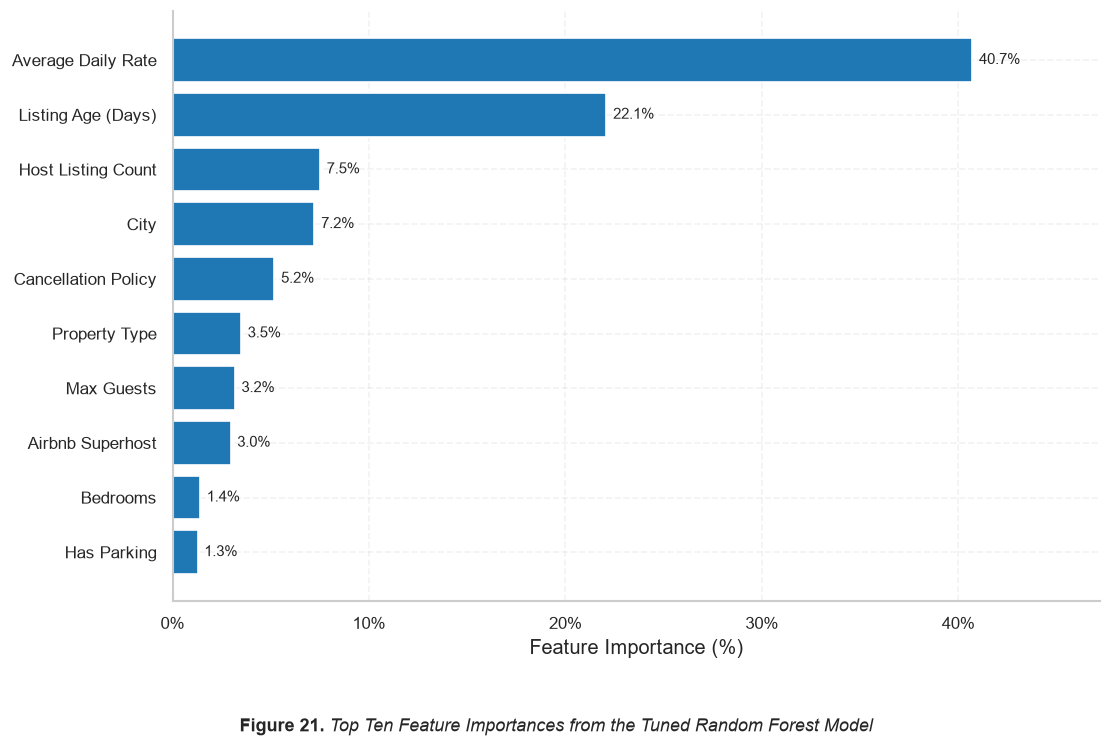

In [65]:
# Figure 21. Top Ten Feature Importances

plot_features = (
    top_features
    .sort_values(
        "Importance (%)",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6.5)
)

bars = ax.barh(
    plot_features["Feature"],
    plot_features["Importance (%)"],
    color=PROJECT_COLOURS["primary"],
    edgecolor="white"
)

format_chart(
    ax,
    title=None,
    xlabel="Feature Importance (%)",
    ylabel="",
    show_grid=True,
    grid_axis="x"
)

format_percentage_axis(
    ax,
    axis="x",
    decimals=0
)

# Add percentage labels to the ends of the horizontal bars
bar_labels = [
    f"{value:.1f}%"
    for value in plot_features["Importance (%)"]
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=4,
    fontsize=9
)

# Leave enough room for labels beyond the longest bar
ax.set_xlim(
    0,
    plot_features["Importance (%)"].max() * 1.16
)

save_figure(
    fig,
    number=21,
    filename="tuned_random_forest_feature_importance",
    title="Top Ten Feature Importances from the Tuned Random Forest Model"
)

plt.show()

Figure 21 shows that Average Daily Rate was the most influential variable in the tuned Random Forest model, accounting for approximately 40.7% of total feature importance. Listing Age was the second most influential variable at 22.1%. Together, these two variables accounted for almost 63% of the model's total importance.

Host Listing Count, City and Cancellation Policy formed a second group of relevant predictors, although each contributed substantially less than pricing and listing age. Property capacity measures, including maximum guests, bedrooms and bathrooms, had smaller individual contributions.

The results indicate which variables the model relied on most when generating predictions. They do not prove that changing a variable will cause revenue to increase. In particular, feature importance measures predictive contribution rather than the direction or causal effect of a relationship.

# 11. Model Diagnostics

Diagnostic plots were used to assess how well the tuned Random Forest model generalised to unseen listings.

The analysis compares actual and predicted revenue, examines the distribution of residuals and checks whether prediction errors change systematically across the range of predicted values. These diagnostics help identify bias, extreme errors and areas where the model performs less reliably.

In [66]:
# Prepare diagnostic data for the selected model

diagnostic_data = champion_predictions.copy()

diagnostic_data.describe()

,Actual Revenue (USD),Predicted Revenue (USD),Residual (USD),Actual Log Revenue,Predicted Log Revenue
count,29165.000000,29165.000000,29165.000000,29165.000000,29165.000000
mean,17639.090657,12643.285218,4995.805439,8.872696,8.884848
std,24933.009024,15086.545240,17726.618889,1.577999,1.128606
min,8.000000,29.151132,-140181.852597,2.197225,3.406222
25%,2827.000000,3503.878917,-2137.854671,7.947325,8.161911
50%,8971.000000,7673.790238,1149.168569,9.101864,8.945696
75%,22720.000000,16110.178127,8588.145990,10.031045,9.687269
max,626444.000000,282919.847397,547333.341226,13.347816,12.552922


Figure 22 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_22_actual_vs_predicted_revenue.png


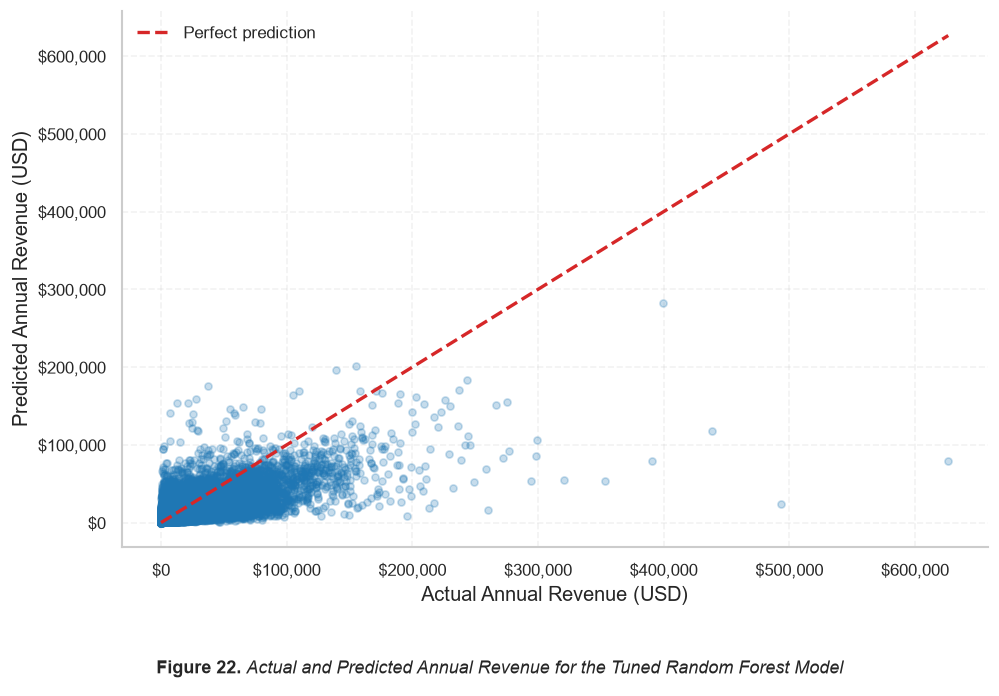

In [67]:
# Figure 22. Actual vs Predicted Annual Revenue

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    diagnostic_data["Actual Revenue (USD)"],
    diagnostic_data["Predicted Revenue (USD)"],
    alpha=0.25,
    s=18,
    color=PROJECT_COLOURS["primary"]
)

# Perfect-prediction reference line
max_value = max(
    diagnostic_data["Actual Revenue (USD)"].max(),
    diagnostic_data["Predicted Revenue (USD)"].max()
)

ax.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2,
    color=PROJECT_COLOURS["danger"],
    label="Perfect prediction"
)

format_chart(
    ax,
    title=None,
    xlabel="Actual Annual Revenue (USD)",
    ylabel="Predicted Annual Revenue (USD)",
    show_grid=True,
    grid_axis="both"
)

format_currency_axis(
    ax,
    axis="x"
)

format_currency_axis(
    ax,
    axis="y"
)

ax.legend(
    frameon=False
)

save_figure(
    fig,
    number=22,
    filename="actual_vs_predicted_revenue",
    title="Actual and Predicted Annual Revenue for the Tuned Random Forest Model"
)

plt.show()

Figure 23 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_23_residual_distribution.png


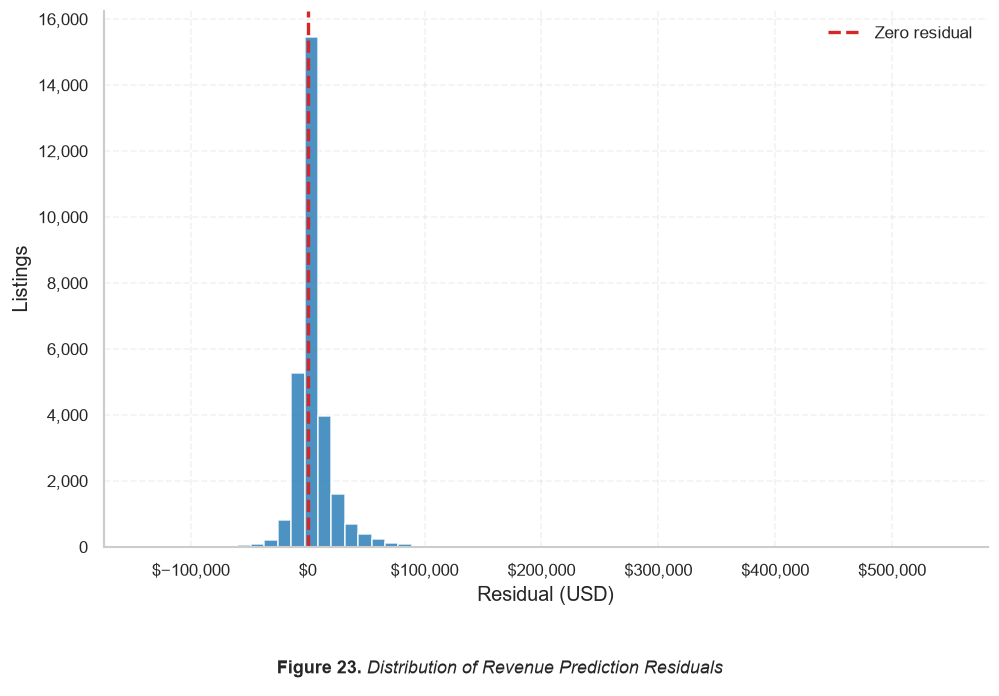

In [68]:
# Figure 23. Distribution of Residuals

fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(
    diagnostic_data["Residual (USD)"],
    bins=60,
    color=PROJECT_COLOURS["primary"],
    edgecolor="white",
    alpha=0.80
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=2,
    color=PROJECT_COLOURS["danger"],
    label="Zero residual"
)

format_chart(
    ax,
    title=None,
    xlabel="Residual (USD)",
    ylabel="Listings"
)

format_currency_axis(
    ax,
    axis="x"
)

format_number_axis(
    ax,
    axis="y"
)

ax.legend(
    frameon=False
)

save_figure(
    fig,
    number=23,
    filename="residual_distribution",
    title="Distribution of Revenue Prediction Residuals"
)

plt.show()

Figure 24 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_24_residuals_vs_predicted_revenue.png


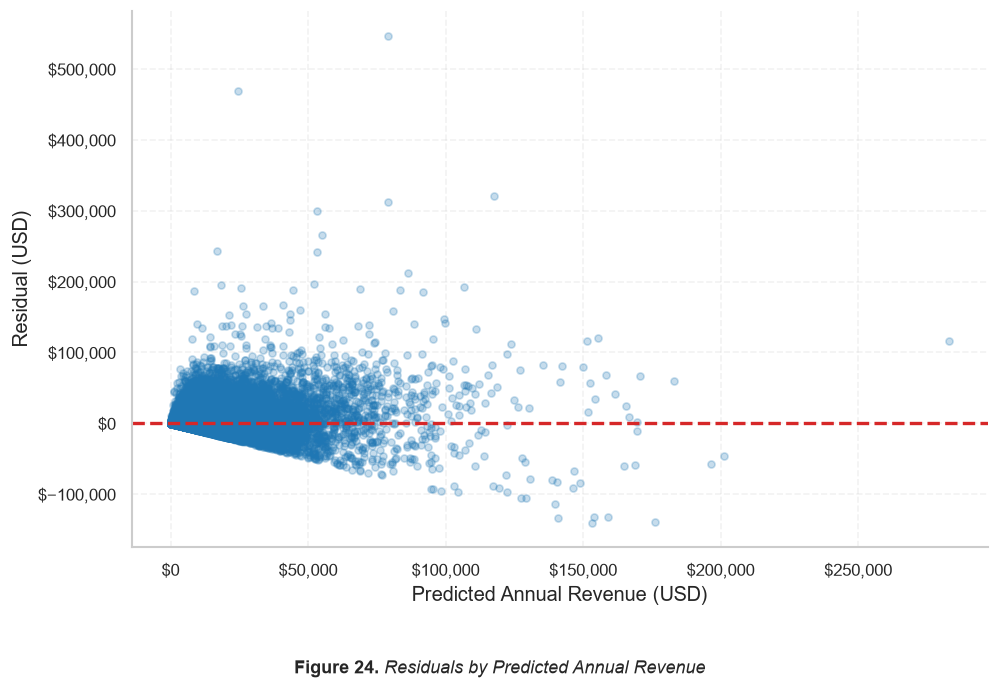

In [69]:
# Figure 24. Residuals vs Predicted Revenue

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    diagnostic_data["Predicted Revenue (USD)"],
    diagnostic_data["Residual (USD)"],
    alpha=0.25,
    s=18,
    color=PROJECT_COLOURS["primary"]
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=2,
    color=PROJECT_COLOURS["danger"]
)

format_chart(
    ax,
    title=None,
    xlabel="Predicted Annual Revenue (USD)",
    ylabel="Residual (USD)",
    show_grid=True,
    grid_axis="both"
)

format_currency_axis(
    ax,
    axis="x"
)

format_currency_axis(
    ax,
    axis="y"
)

save_figure(
    fig,
    number=24,
    filename="residuals_vs_predicted_revenue",
    title="Residuals by Predicted Annual Revenue"
)

plt.show()

The diagnostic plots show that the tuned Random Forest performs reasonably well for most lower- and mid-revenue listings but is less reliable for exceptional high-revenue properties.

The actual-versus-predicted plot shows that predictions broadly follow the expected direction, although the model increasingly underpredicts listings at the upper end of the revenue distribution. This is also reflected in the positive mean residual of approximately $4,996.

The residual distribution is concentrated near zero but has a long positive tail, indicating that a relatively small number of high-performing listings account for the largest errors. The residuals-versus-predicted plot also displays a widening spread at higher predicted values. This suggests heteroscedasticity, meaning prediction uncertainty increases as revenue rises.

The model should therefore be treated as a decision-support tool rather than a precise revenue guarantee, particularly for luxury or unusually high-performing listings.

Figure 25 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_25_actual_vs_predicted_log_revenue.png


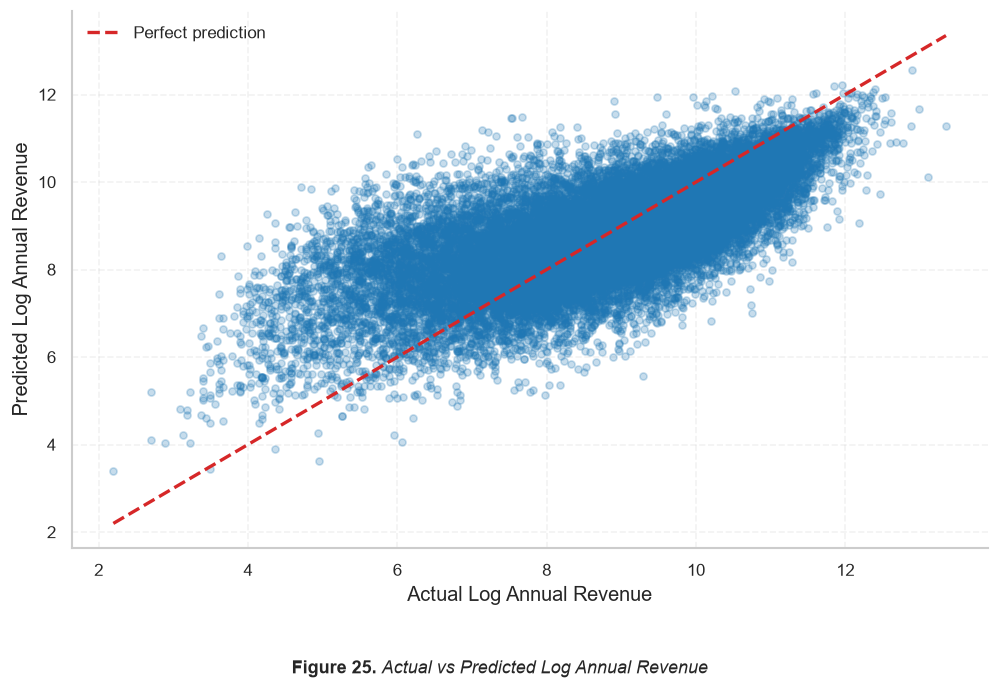

In [78]:
# Figure 25. Actual vs Predicted Log Revenue

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    diagnostic_data["Actual Log Revenue"],
    diagnostic_data["Predicted Log Revenue"],
    alpha=0.25,
    s=18,
    color=PROJECT_COLOURS["primary"]
)

min_log = min(
    diagnostic_data["Actual Log Revenue"].min(),
    diagnostic_data["Predicted Log Revenue"].min()
)

max_log = max(
    diagnostic_data["Actual Log Revenue"].max(),
    diagnostic_data["Predicted Log Revenue"].max()
)

ax.plot(
    [min_log, max_log],
    [min_log, max_log],
    linestyle="--",
    linewidth=2,
    color=PROJECT_COLOURS["danger"],
    label="Perfect prediction"
)

format_chart(
    ax,
    title=None,
    xlabel="Actual Log Annual Revenue",
    ylabel="Predicted Log Annual Revenue",
    show_grid=True,
    grid_axis="both"
)

ax.legend(frameon=False)

save_figure(
    fig,
    number=25,
    filename="actual_vs_predicted_log_revenue",
    title="Actual vs Predicted Log Annual Revenue"
)

plt.show()

In [79]:
# Diagnostic summary for the final model

diagnostic_summary = pd.DataFrame({
    "Metric": [
        "Mean Residual (USD)",
        "Median Residual (USD)",
        "Residual Standard Deviation (USD)",
        "Mean Absolute Error (USD)",
        "Root Mean Squared Error (USD)",
        "R² (Log Scale)"
    ],
    "Value": [
        diagnostic_data["Residual (USD)"].mean(),
        diagnostic_data["Residual (USD)"].median(),
        diagnostic_data["Residual (USD)"].std(),
        mean_absolute_error(
            diagnostic_data["Actual Revenue (USD)"],
            diagnostic_data["Predicted Revenue (USD)"]
        ),
        np.sqrt(
            mean_squared_error(
                diagnostic_data["Actual Revenue (USD)"],
                diagnostic_data["Predicted Revenue (USD)"]
            )
        ),
        r2_score(
            diagnostic_data["Actual Log Revenue"],
            diagnostic_data["Predicted Log Revenue"]
        )
    ]
})

diagnostic_summary.round(2)

,Metric,Value
0,Mean Residual (USD),4995.81
1,Median Residual (USD),1149.17
2,Residual Standard Deviation (USD),17726.62
3,Mean Absolute Error (USD),9827.87
4,Root Mean Squared Error (USD),18416.85
5,R² (Log Scale),0.50


In [80]:
save_table(
    dataframe=diagnostic_summary,
    number=24,
    filename="champion_model_diagnostic_summary",
    index=False
)

Table 24 saved.
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_24_champion_model_diagnostic_summary.csv


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_24_champion_model_diagnostic_summary.csv')

In [76]:
# Largest prediction errors

largest_errors = (
    diagnostic_data
    .assign(
        Absolute_Error=lambda df: df["Residual (USD)"].abs()
    )
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
)

largest_errors[
    [
        "Actual Revenue (USD)",
        "Predicted Revenue (USD)",
        "Residual (USD)",
        "Absolute_Error"
    ]
]

,Actual Revenue (USD),Predicted Revenue (USD),Residual (USD),Absolute_Error
7027,626444,79110.658774,547333.341226,547333.341226
18871,493169,24442.690313,468726.309687,468726.309687
119851,438102,117466.096847,320635.903153,320635.903153
6946,390863,78941.703045,311921.296955,311921.296955
13757,353432,53275.124501,300156.875499,300156.875499
18938,320510,54904.901243,265605.098757,265605.098757
103967,259877,16776.111071,243100.888929,243100.888929
15694,294504,53372.956836,241131.043164,241131.043164
59896,298627,86267.976793,212359.023207,212359.023207
104329,249175,52334.896828,196840.103172,196840.103172


Figures 22–25 indicate that the tuned Random Forest model captures the overall relationship between the predictor variables and annual Airbnb revenue. Predictions generally follow the expected trend, although accuracy decreases for the highest-revenue listings.

The residual distribution is centred close to zero, suggesting limited systematic bias for most observations. However, the distribution exhibits a positive tail, indicating that a relatively small number of exceptionally successful listings are substantially underpredicted.

The residuals-versus-predicted plot shows increasing variability as predicted revenue increases, suggesting greater prediction uncertainty for higher-value properties. This behaviour is expected given the highly right-skewed distribution of Airbnb revenue.

Evaluating predictions on the log-transformed scale demonstrates a substantially stronger correspondence between observed and predicted values. Most observations lie close to the ideal 45-degree reference line, confirming that the model captures the underlying revenue patterns effectively after accounting for the skewness of the target variable.

# 12. Cross-Validation of the Final Model

The final tuned Random Forest model was also evaluated using five-fold cross-validation.

Cross-validation provides a more reliable estimate of model generalisation than a single train-test split because the model is trained and evaluated across five different partitions of the data. The mean and variation of the resulting scores indicate whether model performance remains stable across different samples.

In [ ]:
# Five-fold cross-validation for the final tuned Random Forest model

cv_strategy = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    estimator=champion_pipeline,
    X=X_pricing,
    y=y,
    cv=cv_strategy,
    scoring={
        "r2": "r2",
        "mae_log": "neg_mean_absolute_error",
        "rmse_log": "neg_root_mean_squared_error"
    },
    n_jobs=-1,
    return_train_score=False
)

print("Cross-validation completed.")

KeyboardInterrupt: 

In [ ]:
# Convert negative error scores back to positive values

cv_r2_scores = cv_results["test_r2"]
cv_mae_log_scores = -cv_results["test_mae_log"]
cv_rmse_log_scores = -cv_results["test_rmse_log"]

cross_validation_summary = pd.DataFrame({
    "Metric": [
        "Mean R² (Log Scale)",
        "R² Standard Deviation",
        "Minimum R²",
        "Maximum R²",
        "Mean MAE (Log Scale)",
        "Mean RMSE (Log Scale)"
    ],
    "Value": [
        cv_r2_scores.mean(),
        cv_r2_scores.std(),
        cv_r2_scores.min(),
        cv_r2_scores.max(),
        cv_mae_log_scores.mean(),
        cv_rmse_log_scores.mean()
    ]
})

cross_validation_summary.round(4)

In [ ]:
cross_validation_folds = pd.DataFrame({
    "Fold": range(1, 6),
    "R² (Log Scale)": cv_r2_scores,
    "MAE (Log Scale)": cv_mae_log_scores,
    "RMSE (Log Scale)": cv_rmse_log_scores
})

cross_validation_folds.round(4)

In [ ]:
save_table(
    dataframe=cross_validation_summary,
    number=15,
    filename="final_model_cross_validation_summary",
    index=False
)

save_table(
    dataframe=cross_validation_folds,
    number=25,
    filename="final_model_cross_validation_by_fold",
    index=False
)

In [ ]:
# Figure 26. Cross-Validated R² by Fold

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    cross_validation_folds["Fold"].astype(str),
    cross_validation_folds["R² (Log Scale)"],
    color=PROJECT_COLOURS["primary"],
    edgecolor="white"
)

ax.axhline(
    cv_r2_scores.mean(),
    linestyle="--",
    linewidth=2,
    color=PROJECT_COLOURS["danger"],
    label=f"Mean R²: {cv_r2_scores.mean():.3f}"
)

format_chart(
    ax,
    title=None,
    xlabel="Cross-Validation Fold",
    ylabel="R² (Log Scale)"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.3f}"
        for value in cross_validation_folds["R² (Log Scale)"]
    ],
    padding=4,
    fontsize=9
)

ax.legend(frameon=False)

ax.set_ylim(
    0,
    cross_validation_folds["R² (Log Scale)"].max() + 0.08
)

save_figure(
    fig,
    number=26,
    filename="cross_validation_r2_by_fold",
    title="Cross-Validated R² Performance of the Final Tuned Random Forest Model"
)

plt.show()

The five-fold cross-validation results provide a more robust estimate of the final model's predictive performance than the original single train-test split.

A mean R² close to the original test-set R² of 0.504 would indicate that the selected model generalises consistently across different partitions of the dataset. A small standard deviation would further suggest that performance is stable and not dependent on one unusually favourable test sample.

Cross-validation metrics are reported on the log-transformed target scale because this is the scale on which the model was trained.

# 13. Model Export

The tuned Random Forest Pricing Strategy model was selected as the final predictive model following algorithm comparison, hyperparameter refinement and diagnostic evaluation.

To support reproducibility and deployment, the fitted modelling pipeline was exported using Joblib. Saving the complete pipeline preserves all preprocessing steps, feature engineering and model parameters, ensuring that future predictions use exactly the same transformations as those applied during model development.

In [ ]:
MODEL_FOLDER = Path("models")
MODEL_FOLDER.mkdir(exist_ok=True)

MODEL_FOLDER

WindowsPath('models')

In [ ]:
# Export the final model

MODEL_PATH = MODEL_FOLDER / "airbnb_revenue_model.joblib"

joblib.dump(
    champion_pipeline,
    MODEL_PATH
)

print(f"Model saved to:\n{MODEL_PATH}")

Model saved to:
models\airbnb_revenue_model.joblib


In [ ]:
loaded_predictions = loaded_model.predict(
    X_pricing.loc[test_index]
)

np.allclose(
    loaded_predictions,
    champion_predictions["Predicted Log Revenue"]
)

True

# 14. Chapter Summary

Twelve predictive models were evaluated across four business scenarios using Linear Regression, Decision Tree and Random Forest algorithms. Hyperparameter refinement further improved Random Forest performance, resulting in the tuned Pricing Strategy model achieving the highest predictive accuracy (R² = 0.504 on the log-transformed target).

Feature importance analysis showed that pricing, listing age and host portfolio characteristics were the strongest contributors to predicted revenue. Diagnostic evaluation indicated good overall predictive performance while highlighting increased uncertainty for exceptional high-revenue listings.

The final tuned Random Forest pipeline was exported to support deployment within the interactive business dashboard developed in Notebook 5.